### Group Members:

- Name, matriculation number
- Name, matriculation number
- Name, matriculation number

# Assignment 1: Universal Function Approximator


The goal of this exercise is to compare three different neural network architectures and analyze their capacity for function approximation:

1. $N_0$: One-layer network (linear transformation only)
2. $N_1$: One-layer network with non-linear activation function
3. $N_2$: Two-layer network (hidden layer with non-linear activation function)

They will be trained via gradient descent with weight decay. 
To show the flexibility of the approach, three different functions will be approximated:
1. $X_0: t = \sin(2x)$ for $x\in[-2,2]$
2. $X_1: t = e^{-x^2}$ for $x\in[-3,3]$
3. $X_2: t = -x^5 - 3x^4 + 11x^3 +27x^2 - 10x - 32$ for $x\in[-4.5,3.5]$

In the theoretical section, the networks will be designed, and the necessary derivatives will be computed by hand.

In the coding section, we will: 

- implement the networks and their gradients,
- generate target data for three different functions, 
- apply the training procedure to the data, and 
- plot the resulting approximated function together with the data samples.

## Section 1: Theoretical Questions

### Network Design

#### Task 1.1: Network Structure

Given input $\vec x = (1, x)^T$, define three neural networks ($N_0$, $N_1$, $N_2$) mathematically, to reach output $y$. Use $g()$ to represent the activation function.

Explain how their structures differ and analyze their function approximation capabilities.

--- 
Note:

For one-layer networks, define parameter $\Theta=\vec w \in\mathbb R^{D+1}$

For two-layer network, define parameters $\Theta=(\mathbf W^{(1)},\vec w^{(2)})$ that are split into $\mathbf W^{(1)}\in\mathbb R^{K\times {(D+1)}}$ for the first layer and $\vec w^{(2)}\in\mathbb R^{K+1}$ for the second layer

$N_0$: Only linear forms can be expressed, making complex function representations difficult.
$N_1$: Although nonlinear, it has limited expressiveness due to having only one neuron.
$N_2$: It can approximate complex curves because it uses multiple hidden neurons.

#### Task 1.2: Network Comparison

Can the one-layer network approximate all three functions well? 
Why or why not?

What advantages does the two-layer network have compared to a one-layer network?

How can we determine the appropriate number of hidden neurons?
When looking at the example plots in the OLAT, how many hidden neurons do we need in order to approximate the functions? 
Is there any difference between the three target functions?




The three models differ in their expressive power.

The linear model N₀ can only represent straight lines. Therefore it cannot approximate nonlinear functions such as sinusoidal or oscillating patterns in the dataset.

Model N₁ introduces a nonlinear activation function. This allows the model to represent nonlinear relationships, but its flexibility is still limited because it has only a single neuron.

Model N₂ contains a hidden layer with multiple neurons. Each neuron produces a nonlinear transformation of the input, and the output layer combines these activations. With enough hidden neurons, this model can approximate very complex functions.

Therefore, N₂ is significantly more expressive than N₀ and N₁.

#### Task 1.3: Network Performance

If the network struggles to approximate a function well, what are some possible reasons?

How can we improve the network's performance?


##### Reasons
The model may be too simple.
The number of hidden neurons may be insufficient.
The learning rate may be too large or too small.
Weight decay may be too strong.
The initial weights may be suboptimal.

##### Solutions
Use a more powerful model.
Increase the number of hidden neurons.
Adjust the learning rate.
Adjust Weight decay λ appropriately.
Train for longer.

### Derivatives

#### Task 1.4: Activation Function

Given the hyperbolic tangent ($\tanh$) activation function as:

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Prove:

$$\frac{\partial}{\partial x} \tanh(x) = 1 - \tanh^2(x)$$

Hint: Apply the derivative rules as defined in the Lecture:
* Quotient rule
* Sum rule
* Exponential rule

Also, avoid factoring out parentheses.



The hyperbolic tangent function is defined as

tanh(x) = (e^x − e^−x) / (e^x + e^−x)

To compute its derivative, we differentiate the expression using standard calculus rules.

The derivative of tanh(x) simplifies to

d/dx tanh(x) = 1 − tanh²(x)

This result is very convenient for neural networks because the derivative can be expressed directly in terms of the activation function itself.

#### Task 1.5: Weight Decay

Consider a loss function with L2 regularization (weight decay):
$$
\mathcal J'_\Theta = \mathcal J_\Theta + \frac{\lambda}{2} \|\Theta\|^2
$$

Expecting the gradient of the network $\nabla \mathcal J_\Theta$ to be given, compute the derivative of $\mathcal J'$ with respect to all $\Theta_i$: $$\biggl[\frac{\partial}{\partial \Theta_i} \mathcal J'_\Theta\biggr]_i$$

$\frac{\partial}{\partial \Theta_i} \mathcal J'_\Theta = J(Θ) + (λ/2) ||Θ||²

where λ is the regularization parameter and ||Θ||² represents the squared norm of the weights.

Taking the derivative with respect to Θᵢ gives

∂J'/∂Θᵢ = ∂J/∂Θᵢ + λΘᵢ

The additional term λΘᵢ penalizes large weights. This technique is known as weight decay and helps prevent overfitting by encouraging smaller parameter values.

#### Task 1.6

How large should an appropriate weight decay parameter $\lambda$ as shown in Task 1.5 be? What would happen if $\lambda$ is set too high or too low?


Equidistant points are points that are evenly spaced along an interval. For example, if we generate points between −3 and 3 with equal spacing, the distance between consecutive points is constant.

Equidistant sampling is often used when generating synthetic datasets because it ensures that the input space is uniformly covered.

In practice, equidistant points can be generated using functions such as

x = np.linspace(a, b, n)

where a and b define the interval and n is the number of points.

## Section 2: Coding

**<font color='red' size='5'>This section has to be submitted by 11:59 p.m. on Wednesday, March 11th, to be graded.</font>**



### Network Implementation
#### Task 2.1

Recall that for one-layer networks, we define parameter $\Theta=\vec w \in\mathbb R^{D+1}$, and for a two-layer network, we define parameters $\Theta=(\mathbf W^{(1)}\in\mathbb R^{K\times {(D+1)}},\vec w^{(2)}\in\mathbb R^{K+1})$.

- D: The dimension of the input. In this assignment, $D = 1$ since there is only one input.
- K: The number of neurons in the hidden layer of the two-layer network ($N_2$)

Implement a function that returns the network output for a given input $\vec x$, model_type ($N_0$, $N_1$, or $N_2$) and parameters $\Theta$. 
Remember that the input of the function $\vec x = (1, x)^T$.

---
Note:

1. Use the `numpy` to implement the $\tanh$ function.
2. Use `numpy.concatenate` or `numpy.insert` to prepend $h_0$.
3. Make use of `numpy.dot` to compute matrix-vector and vector-vector products.

In [106]:
from math import tanh

import numpy 
import matplotlib.pyplot as plt

def network(x, model_type, Theta):
    """
    Compute the output of a neural network model.

    Args:
        x: Input vector (1, x) including bias.
        model_type: Type of model (0, 1, or 2).
        Theta: Tuple of network parameters (W1, w2).

    Returns:
        y: Network output.
        h: Hidden layer output, or None.
    """

    W1, w2 = Theta # w2 is None if model_type is 1 or 2
    x = numpy.asarray(x, dtype=float)


    if model_type == 0:
        # One-layer network (Linear Model)
        y = W1 @ x
        return y, None # To make this consistent when model_type is 3

    elif model_type == 1:
        # One-layer network with tanh activation
        y = numpy.tanh(W1 @ x)
        return y, None # To make this consistent when model_type is 3

    elif model_type == 2:
        # Two-layer network with tanh activation
        a_ = W1 @ x
        h_ = numpy.tanh(a_)
        h = numpy.insert(h_, 0, 1) # Add bias term to hidden layer output
        y = w2 @ h
        return y, h

#### Test 1: Sanity Check

We select a specific number of hidden neurons and create the weights accordingly, using all zeros in the first layer and all ones in the second. The test case below ensures that the function from Task 1 actually returns $11$ for those weights.

In [107]:
# Define test parameters
K_ = 20
D_ = 1
Theta_one_layer = [numpy.ones(D_+1),None]
Theta_two_layer = [numpy.zeros((K_, D_+1)), numpy.ones(K_+1)]
x = numpy.random.rand(D_+1)

# Sanity check for N1
y1, _ = network(x, 0, Theta_one_layer)
assert abs(numpy.sum(x) - y1) < 1e-6
print("N1 test passed.")

# Sanity check for N2
y2, _ = network(x, 1, Theta_one_layer)
assert abs(numpy.tanh(numpy.sum(x)) - y2) < 1e-6
print("N2 test passed.")

# Sanity check for N3
y3, _ = network(x, 2, Theta_two_layer)
assert abs(1.0 - y3) < 1e-6
print("N3 test passed.")

N1 test passed.
N2 test passed.
N3 test passed.


### Gradient Implementation

#### Task 2.2: Gradient Computation


Implementation of a function that returns the gradient as defined for a given dataset $X=\{(\vec x^{[n]}, t^{[n]})\}$, model_type, parameters $\Theta$, and the $\lambda$ parameter for weight decay.

---
Note:

You should make sure that both parts of the gradient are computed for $N_2$ (since $\Theta=(\mathbf W^{(1)},\vec w^{(2)})$ here).

This is a very slow implementation. We will see how to speed this up in the next lecture.

In [108]:
def compute_gradient(X, model_type, Theta, lambda_=1.):
    """
    Compute the gradient of the loss function with respect to the weights for each model type.

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        lambda_: Weight decay parameter. Default is 1.0.

    Returns:
        Gradients with respect to W1 and w2. For model_type 1 and 2, w2 is None.
    """

    # split parameters for easier handling
    W1, w2 = Theta # w2 is None if model_type is 1 or 2

    # define gradient with respect to both parameters
    dW1 = numpy.zeros_like(W1)
    dw2 = None if w2 is None else numpy.zeros_like(w2) # dw2 is None if model_type is 1 or 2

    # iterate over dataset
    for x, t in X:
        # get network output
        y, h = network(x, model_type, (W1, w2))
        err = y - t

        # compute and aggregate the gradient, based on the network type
        if model_type == 0:
            dW1 += err * x

        elif model_type == 1:
            dW1 += err * (1 - y**2) * x # derivative of tanh is 1 - tanh^2

        elif model_type == 2:
            dw2 += err * h
            dW1 += (w2[1:].T * err * (1 - h[1:]**2))[:, None] * x # chain rule for two-layer network

    # Add penalty term/weight decay
    N = len(X)
    dW1 = dW1 / N + lambda_ * W1

    # anything else?

    if model_type == 2:
        dw2 = dw2 / N + lambda_ * w2

    return dW1, dw2



#### Task 2.3: Gradient Descent

The procedure of gradient descent is the repeated application of two steps.

1. The gradient of loss $\nabla_{\Theta}\mathcal J^{L_2}$ is computed based on the current value of the parameters $\Theta$.
2. The weights are updated by moving a small step in the direction of the negative gradient:

$$
\begin{align}
    \Theta = \Theta - \eta \nabla_{\Theta}\mathcal J
\end{align}
$$

As a stopping criterion, we select the number of training epochs to be 10000.

Implementation of a function that performs gradient descent for a given dataset $X$, given initial parameters $\Theta$, a given learning rate $\eta$, model_type ($N_1$, $N_2$, or $N_3$), and $\lambda$ parameter for weight decay, and returns the optimized parameters $\Theta^*$.

In [109]:
def gradient_descent(X, model_type, Theta, eta, lambda_=1., epochs=10000):
    """
    Perform gradient decent for each model type.

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        eta: Learning rate.
        lambda_: Weight decay parameter. Default is 1.0.
        epochs: The number of epochs to train for

    Returns:
        The optimized model parameters
    """
    W1 = numpy.array(Theta[0], dtype=float)
    w2 = None if Theta[1] is None else numpy.array(Theta[1], dtype=float)


    # perform iterative gradient descent
    for _ in range(epochs):
        # compute the gradient
        dW1, dw2 = compute_gradient(X, model_type, (W1, w2), lambda_)


        # update the parameters
        W1 = W1 - eta * dW1
        if model_type == 2:
            w2 = w2 - eta * dw2

    # return optimized parameters


    return [W1, w2]


### Datasets

#### Task 2.4: Data Samples

In total, we will test our gradient descent function with three different datasets. Particularly, we approximate

1. $X_0: t = \sin(2x)$ for $x\in[-2,2]$
2. $X_1: t = e^{-x^2}$ for $x\in[-3,3]$
3. $X_2: t = -x^5 - 3x^4 + 11x^3 +27x^2 - 10x - 32$ for $x\in[-4.5,3.5]$

Generate dataset $X_0$ for $N=45$ samples randomly drawn from range $x\in[-2,2]$. 
Generate dataset $X_1$ for $N=15$ samples randomly drawn from range $x\in[-3,3]$. 
Generate dataset $X_2$ for $N=250$ samples randomly drawn from range $x\in[-4.5,3.5]$. 
Implement all three datasets as lists of tuples: $\{(\vec x^{[n]}, t^{[n]})\mid 1\leq n\leq N\}$

In [110]:
#X0 = [...]
#X1 = [...]
#X2 = [...]


rng = numpy.random.default_rng()

# X0
X0 = []
for x in rng.uniform(-2,2,45):
    t = numpy.sin(2*x)
    X0.append((numpy.array([1,x]), t))


# X1
X1 = []
for x in rng.uniform(-3,3,15):
    t = numpy.exp(-x**2)
    X1.append((numpy.array([1,x]), t))


# X2
X2 = []
for x in rng.uniform(-4.5,3.5,250):
    t = -x**5 - 3*x**4 + 11*x**3 +27*x**2 -10*x -32
    X2.append((numpy.array([1,x]), t))

#### Test 2: Sanity Check

The test case below ensures that the elements of each generated dataset are tuples with two dimensions.
It does not test that the values are correct.

In [111]:
for i, X in enumerate((X0, X1, X2)):
    assert all(
        isinstance(x, (tuple, list)) and
        len(x) == 2 and
        isinstance(x[0], (tuple, list, numpy.ndarray)) and
        len(x[0]) == 2 and
        isinstance(x[1], (float, numpy.float32, numpy.float64))
        for x in X
    ), f"Test failed for dataset X{i}"

print('Test passed!')

Test passed!


### Function Approximation
Finally, we want to make use of our gradient descent implementation to approximate our functions. In order to see our success, we want to plot the functions together with the data.

#### Task 2.5: Define Hidden Neurons
How many hidden neurons will we need for $N_2$? Use the answers from Task 1.2.

In [112]:
# Define the number of neurons for each target function based on your discussion
K0 = 8
K1 = 6
K2 = 20

#### Task 2.6: Random Parameters

For each of the networks, randomly initialize the parameters $\Theta_0,\Theta_1,\Theta_2\in[-1,1]$ for each of the datasets.

For $N_2$, use the number of hidden neurons estimated in Task 1.2 and implemented in Task 2.5.

---
Note:

  1. You can use `numpy.random.uniform` to initialize the weights.
  2. Make sure that the weight matrices are instantiated in the correct dimensions.
  3. Theta should always have two elements. The second element can be `None` for one-layer networks.


In [113]:
D=1
import numpy as np
rng = np.random.default_rng(42)

# Initialize weights for One-Layer Network (No Activation), once for each dataset
Thetas_N0 = [
    [rng.uniform(-1, 1, size=D+1), None],
    [rng.uniform(-1, 1, size=D+1), None],
    [rng.uniform(-1, 1, size=D+1), None]
]

# Initialize weights for One-Layer Network (With Activation)
Thetas_N1 = [
    [rng.uniform(-1, 1, size=D+1), None],
    [rng.uniform(-1, 1, size=D+1), None],
    [rng.uniform(-1, 1, size=D+1), None]
]

# Initialize weights for Two-Layer Network
Thetas_N2 = [
    [rng.uniform(-1, 1, size=(K0, D+1)), rng.uniform(-1, 1, size=K0+1)],
    [rng.uniform(-1, 1, size=(K1, D+1)), rng.uniform(-1, 1, size=K1+1)],
    [rng.uniform(-1, 1, size=(K2, D+1)), rng.uniform(-1, 1, size=K2+1)]
]

#### Task 2.7: Run Gradient Descent

For each network, call gradient descent function from Task 2.3 using the datasets $X_0, X_1, X_2$, the according created parameters $\Theta_0,\Theta_1,\Theta_2$.
Store the resulting optimized weights $\Theta_0^*, \Theta_1^*, \Theta_2^*$.

Based on your chosen learning rates $\eta$ and weight decay parameter $\lambda$, you may need to optimize them for these functions. 
Do you see any differences? 
What are the best learning rates that you can find?

---
<span style="color:red">WARNING: Depending on the implementation, this might run for several minutes!</span>

---
Hints:

1. Start with $\eta=0.1$ and play around with the learning rate improve adaptation.
2. $\eta=0.1$ might be too large for $X_2$.

In [114]:
# Call gradient descent function using the datasets and initial weights that you created above
# Choose appropriate learning rates for each function

lambda_ = 1e-4

# N0
Theta0_X0 = gradient_descent(X0, 0, Thetas_N0[0], eta=0.01,  lambda_=lambda_, epochs=10000)
Theta0_X1 = gradient_descent(X1, 0, Thetas_N0[1], eta=0.01,  lambda_=lambda_, epochs=10000)
Theta0_X2 = gradient_descent(X2, 0, Thetas_N0[2], eta=1e-4,  lambda_=lambda_, epochs=10000)

# N1
Theta1_X0 = gradient_descent(X0, 1, Thetas_N1[0], eta=0.01,  lambda_=lambda_, epochs=10000)
Theta1_X1 = gradient_descent(X1, 1, Thetas_N1[1], eta=0.01,  lambda_=lambda_, epochs=10000)
Theta1_X2 = gradient_descent(X2, 1, Thetas_N1[2], eta=1e-4,  lambda_=lambda_, epochs=10000)

# N2
Theta2_X0 = gradient_descent(X0, 2, Thetas_N2[0], eta=0.01,  lambda_=lambda_, epochs=10000)
Theta2_X1 = gradient_descent(X1, 2, Thetas_N2[1], eta=0.01,  lambda_=lambda_, epochs=10000)
Theta2_X2 = gradient_descent(X2, 2, Thetas_N2[2], eta=5e-4,  lambda_=lambda_, epochs=10000)

### Data and Function Plotting

### Task 2.8: Plotting Function

Implement a plotting function that takes a given dataset $X$, model_type, parameters $\Theta$, and a defined range $R=[\min,\max]$. 
Each data sample $(\vec x^{[n]}, t^{[n]})$ of the dataset is plotted as an ''x''. 
In order to plot the function that is approximated by the network, generate sufficient equally-spaced input values $x\in R$, compute the network output $y$ for these inputs, and plot them with a line.

---
Hints:

  1. The dataset $X$ is defined as above, a list of tuples $(\vec x, t)$.
  2. Each input in the dataset is defined as $\vec x = (1,x)^T$.
  3. Equidistant points can be obtained via `numpy.arange`.


In [115]:
from matplotlib import pyplot
def plot(X, model_type, Theta, R):
    """
    Plots the data and the network output into one plot

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        R: The range for which we plot the model output

    Returns:
        The optimized model parameters
    """
    # first, plot data samples
    xs_data = [sample[0][1] for sample in X]
    ts_data = [sample[1] for sample in X]
    pyplot.plot(xs_data, ts_data, "rx", label="Data")


    # define equidistant points from min (R[0]) to max (R[1]) to evaluate the network
    # equally spaced x values
    x = np.arange(R[0], R[1], 0.01)
    
    # model outputs
    y = [network(np.array([1.0, xi]), model_type, Theta)[0] for xi in x]


    # plot network approximation
    pyplot.plot(x, y, "k-", label="Network")
    pyplot.legend()

#### Task 2.9: Plot Three Functions for three datasets

For each of the datasets and for each network type including their according optimized parameters, call the plotting function from Task 2.8. 
Use range $R=[-3,3]$ for dataset $X_0$, range $R=[-4,4]$ for $X_1$, and range $R=[-6,5]$ for dataset $X_2$.

Note that the first element of range $R$ should be the lowest $x$-location, and the second element of $R$ the highest value for $x$.

Repeat for three networks.

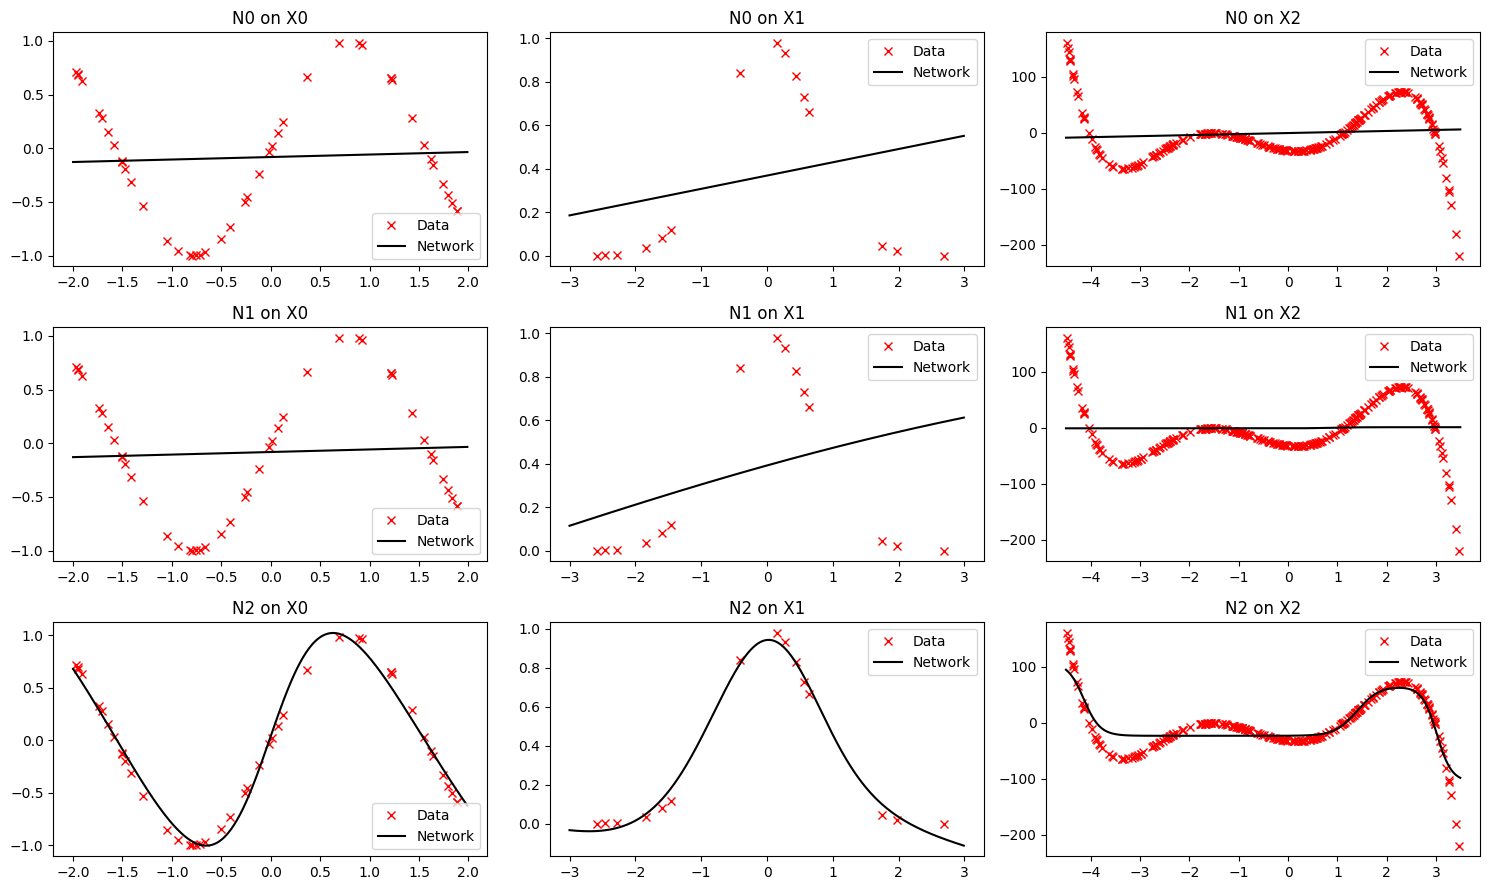

In [116]:
# create one large figure
figure = pyplot.figure(figsize=(15,9))
trained_thetas = [
    [Theta0_X0, Theta0_X1, Theta0_X2],   # model_type 0
    [Theta1_X0, Theta1_X1, Theta1_X2],   # model_type 1
    [Theta2_X0, Theta2_X1, Theta2_X2]    # model_type 2
]

ranges = [
    [-2, 2],   # for X0
    [-3, 3],   # for X1
    [-4.5, 3.5]    # for X2
]

# iterate over the model types
for model_type in range(3):
    # iterate over the datasets
    for i, X in enumerate([X0, X1, X2]):
        # activate correct plot
        pyplot.subplot(3, 3, 3*model_type+i+1)
        # call the plot function with the correct dataset with their ranges, and model type with their trained Theta parameters
        plot(X, model_type, trained_thetas[model_type][i], ranges[i])
        pyplot.title(f"N{model_type} on X{i}")
        
pyplot.tight_layout()
pyplot.show()